<a href="https://colab.research.google.com/github/Varapurnakarthik1/ELECTRICAL-NETWORK-NATURAL-MODES-/blob/main/B9_Electrical_Network_Natural_Modes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# ============================================================
# B9 - ELECTRICAL NETWORK NATURAL MODES
# B.Tech Mathematics Mini Project
# ============================================================

print("=" * 65)
print("       ELECTRICAL NETWORK NATURAL MODES (B9)")
print("=" * 65)

print("""
Objective:
1. Model 3 coupled LC circuits mathematically.
2. Convert the circuit equations into matrix form.
3. Find eigenvalues = squared natural angular frequencies.
4. Find eigenvectors = current distribution of each mode.
5. Convert natural frequencies into Hz.
6. Visualize the modes and resonance behavior.
""")

       ELECTRICAL NETWORK NATURAL MODES (B9)

Objective:
1. Model 3 coupled LC circuits mathematically.
2. Convert the circuit equations into matrix form.
3. Find eigenvalues = squared natural angular frequencies.
4. Find eigenvectors = current distribution of each mode.
5. Convert natural frequencies into Hz.
6. Visualize the modes and resonance behavior.



In [ ]:

# ============================================================
# IMPORTS
# ============================================================

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True)

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:

# ============================================================
# USER CONFIGURATION
# ============================================================

# Inductances
# Unit: Henry (H)
L1 = 10e-3       # 10 mH
L2 = 10e-3       # 10 mH
L3 = 10e-3       # 10 mH

# Mutual inductance
# Must satisfy |M| < sqrt(Li * Lj)
M12 = 2e-3       # 2 mH
M13 = 2e-3       # 2 mH
M23 = 2e-3       # 2 mH

# Capacitances
# Unit: Farad (F)
C1 = 100e-9      # 100 nF
C2 = 100e-9      # 100 nF
C3 = 100e-9      # 100 nF

# ------------------------------------------------------------
# Optional parameters for the driven resonance demonstration
# ------------------------------------------------------------

# Small resistance is added ONLY for the frequency-response plot.
# This prevents an ideal lossless circuit from producing
# mathematically infinite response at resonance.
R = 1.0          # Ohm

# Input voltage amplitude
V_source = 1.0   # Volt

# Frequency sweep
f_min = 100
f_max = 10000
num_points = 5000

print("Input parameters loaded.")

Input parameters loaded.


In [ ]:

# ============================================================
# INPUT VALIDATION
# ============================================================

L_values = [L1, L2, L3]
C_values = [C1, C2, C3]

if any(L <= 0 for L in L_values):
    raise ValueError("All inductances must be positive.")

if any(C <= 0 for C in C_values):
    raise ValueError("All capacitances must be positive.")

# Positive-definite coupled-inductor condition
if abs(M12) >= np.sqrt(L1 * L2):
    raise ValueError("M12 is too large. Require |M12| < sqrt(L1*L2).")

if abs(M13) >= np.sqrt(L1 * L3):
    raise ValueError("M13 is too large. Require |M13| < sqrt(L1*L3).")

if abs(M23) >= np.sqrt(L2 * L3):
    raise ValueError("M23 is too large. Require |M23| < sqrt(L2*L3).")

print("Input validation successful.")

Input validation successful.


In [ ]:

# ============================================================
# MATHEMATICAL MODEL
# ============================================================

L_matrix = np.array([
    [L1,  M12, M13],
    [M12, L2,  M23],
    [M13, M23, L3]
], dtype=float)

C_matrix = np.diag([C1, C2, C3])

C_inverse = np.linalg.inv(C_matrix)

print("Inductance matrix L:")
print(L_matrix)

print("\nCapacitance matrix C:")
print(C_matrix)

print("\nInverse capacitance matrix C^-1:")
print(C_inverse)

Inductance matrix L:
[[0.01  0.002 0.002]
 [0.002 0.01  0.002]
 [0.002 0.002 0.01 ]]

Capacitance matrix C:
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]

Inverse capacitance matrix C^-1:
[[10000000.        0.        0.]
 [       0. 10000000.        0.]
 [       0.        0. 10000000.]]


In [ ]:

# ============================================================
# CIRCUIT EQUATION
# ============================================================

print("\nSECOND-ORDER CIRCUIT EQUATION:")
print()
print("       L * d²i/dt² + C⁻¹ * i = 0")
print()

print("where")
print("i = [i1, i2, i3]^T")
print()

print("For a natural mode:")
print("       i(t) = u * exp(j*w*t)")
print()

print("Therefore:")
print("       (C⁻¹ - w²L)u = 0")
print()

print("or")
print("       L⁻¹ C⁻¹ u = w² u")


SECOND-ORDER CIRCUIT EQUATION:

       L * d²i/dt² + C⁻¹ * i = 0

where
i = [i1, i2, i3]^T

For a natural mode:
       i(t) = u * exp(j*w*t)

Therefore:
       (C⁻¹ - w²L)u = 0

or
       L⁻¹ C⁻¹ u = w² u


In [ ]:

# ============================================================
# EIGENVALUE MATRIX
# ============================================================

# A = L^-1 C^-1
A = np.linalg.solve(L_matrix, C_inverse)

print("Eigenvalue matrix A = L⁻¹ C⁻¹:")
print(A)

Eigenvalue matrix A = L⁻¹ C⁻¹:
[[ 1.071429e+09 -1.785714e+08 -1.785714e+08]
 [-1.785714e+08  1.071429e+09 -1.785714e+08]
 [-1.785714e+08 -1.785714e+08  1.071429e+09]]


In [ ]:
# ============================================================
# EIGENVALUE / EIGENVECTOR CALCULATION
# ============================================================

eigenvalues, eigenvectors = np.linalg.eig(A)

# Numerical round-off can produce tiny imaginary parts.
eigenvalues = np.real(eigenvalues)
eigenvectors = np.real(eigenvectors)

# Natural angular frequencies
omega = np.sqrt(eigenvalues)

# Convert rad/s to Hz
frequency = omega / (2 * np.pi)

# Sort from lowest to highest frequency
order = np.argsort(frequency)

eigenvalues = eigenvalues[order]
omega = omega[order]
frequency = frequency[order]
eigenvectors = eigenvectors[:, order]

# Normalize every eigenvector so that the largest
# absolute current component becomes 1.
for k in range(3):
    eigenvectors[:, k] /= np.max(np.abs(eigenvectors[:, k]))

print("Eigenvalue calculation completed.")

Eigenvalue calculation completed.


In [ ]:

# ============================================================
# OUTPUT TABLE
# ============================================================

print("\n" + "=" * 75)
print("                 NATURAL MODE RESULTS")
print("=" * 75)

print(f"{'Mode':<8}{'Eigenvalue w²':<20}{'ω (rad/s)':<20}{'f (Hz)':<15}")
print("-" * 75)

for k in range(3):
    print(
        f"{k+1:<8}"
        f"{eigenvalues[k]:<20.6e}"
        f"{omega[k]:<20.4f}"
        f"{frequency[k]:<15.4f}"
    )

print("=" * 75)


                 NATURAL MODE RESULTS
Mode    Eigenvalue w²       ω (rad/s)           f (Hz)         
---------------------------------------------------------------------------
1       7.142857e+08        26726.1242          4253.5948      
2       1.250000e+09        35355.3391          5626.9770      
3       1.250000e+09        35355.3391          5626.9770      


In [ ]:

# ============================================================
# CURRENT DISTRIBUTION
# ============================================================

print("\nCURRENT DISTRIBUTION OF EACH NATURAL MODE")
print("=" * 65)

for k in range(3):
    print(f"\nMode {k+1}")
    print(f"Natural frequency = {frequency[k]:.4f} Hz")
    print("Eigenvector [i1, i2, i3]:")

    print(
        f"  i1 = {eigenvectors[0, k]: .6f}\n"
        f"  i2 = {eigenvectors[1, k]: .6f}\n"
        f"  i3 = {eigenvectors[2, k]: .6f}"
    )


CURRENT DISTRIBUTION OF EACH NATURAL MODE

Mode 1
Natural frequency = 4253.5948 Hz
Eigenvector [i1, i2, i3]:
  i1 = -1.000000
  i2 = -1.000000
  i3 = -1.000000

Mode 2
Natural frequency = 5626.9770 Hz
Eigenvector [i1, i2, i3]:
  i1 =  1.000000
  i2 = -0.500000
  i3 = -0.500000

Mode 3
Natural frequency = 5626.9770 Hz
Eigenvector [i1, i2, i3]:
  i1 =  0.445190
  i2 = -1.000000
  i3 =  0.554810


In [ ]:

# ============================================================
# SYMBOLIC MATRIX FORM USING SYMPY
# ============================================================

L1_s, L2_s, L3_s = sp.symbols("L1 L2 L3")
M12_s, M13_s, M23_s = sp.symbols("M12 M13 M23")
C1_s, C2_s, C3_s = sp.symbols("C1 C2 C3")

L_sym = sp.Matrix([
    [L1_s,  M12_s, M13_s],
    [M12_s, L2_s,  M23_s],
    [M13_s, M23_s, L3_s]
])

C_inv_sym = sp.diag(
    1/C1_s,
    1/C2_s,
    1/C3_s
)

print("Symbolic L matrix:")
sp.pprint(L_sym)

print("\nSymbolic C^-1 matrix:")
sp.pprint(C_inv_sym)

print("\nNatural-mode equation:")
print("(C^-1 - w^2 L)u = 0")

Symbolic L matrix:
⎡L₁   M₁₂  M₁₃⎤
⎢             ⎥
⎢M₁₂  L₂   M₂₃⎥
⎢             ⎥
⎣M₁₃  M₂₃  L₃ ⎦

Symbolic C^-1 matrix:
⎡1         ⎤
⎢──  0   0 ⎥
⎢C₁        ⎥
⎢          ⎥
⎢    1     ⎥
⎢0   ──  0 ⎥
⎢    C₂    ⎥
⎢          ⎥
⎢        1 ⎥
⎢0   0   ──⎥
⎣        C₃⎦

Natural-mode equation:
(C^-1 - w^2 L)u = 0


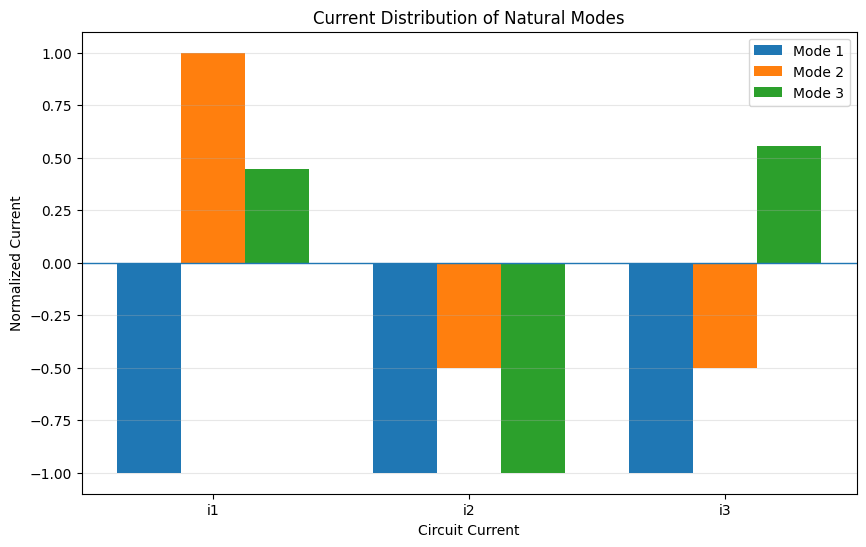

In [ ]:

# ============================================================
# EIGENVECTOR / CURRENT DISTRIBUTION PLOT
# ============================================================

modes = ["Mode 1", "Mode 2", "Mode 3"]
currents = ["i1", "i2", "i3"]

x = np.arange(3)
width = 0.25

plt.figure(figsize=(10, 6))

for k in range(3):
    plt.bar(
        x + (k - 1) * width,
        eigenvectors[:, k],
        width,
        label=f"Mode {k+1}"
    )

plt.axhline(0, linewidth=1)
plt.xticks(x, currents)
plt.xlabel("Circuit Current")
plt.ylabel("Normalized Current")
plt.title("Current Distribution of Natural Modes")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

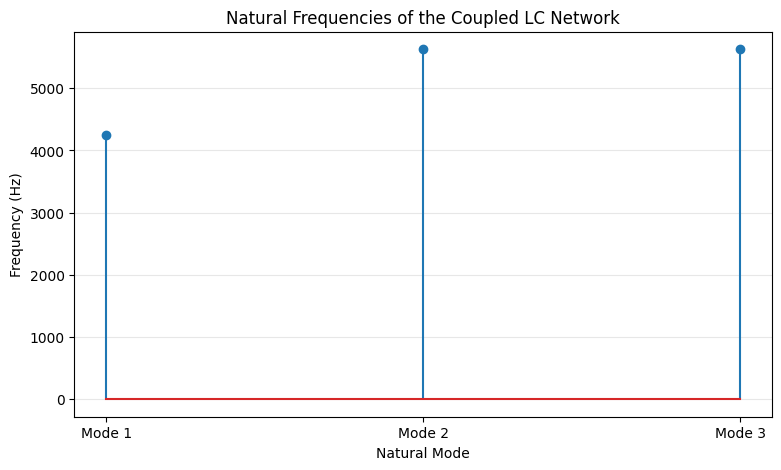

In [ ]:

# ============================================================
# NATURAL FREQUENCY PLOT
# ============================================================

plt.figure(figsize=(9, 5))

plt.stem(
    range(1, 4),
    frequency
)

plt.xlabel("Natural Mode")
plt.ylabel("Frequency (Hz)")
plt.title("Natural Frequencies of the Coupled LC Network")
plt.xticks([1, 2, 3], ["Mode 1", "Mode 2", "Mode 3"])
plt.grid(axis="y", alpha=0.3)

plt.show()

In [ ]:

# ============================================================
# DRIVEN FREQUENCY RESPONSE
# ============================================================

frequencies = np.linspace(f_min, f_max, num_points)

omega_sweep = 2 * np.pi * frequencies

# Source applied to the first loop
V = np.array([V_source, 0, 0], dtype=complex)

# Resistance matrix
R_matrix = R * np.eye(3)

response = np.zeros((3, num_points))

for n, w in enumerate(omega_sweep):

    # Complex impedance matrix
    Z = (
        R_matrix
        + 1j * w * L_matrix
        + C_inverse / (1j * w)
    )

    # Solve Z I = V
    I = np.linalg.solve(Z, V)

    response[:, n] = np.abs(I)

print("Frequency-response calculation completed.")

Frequency-response calculation completed.


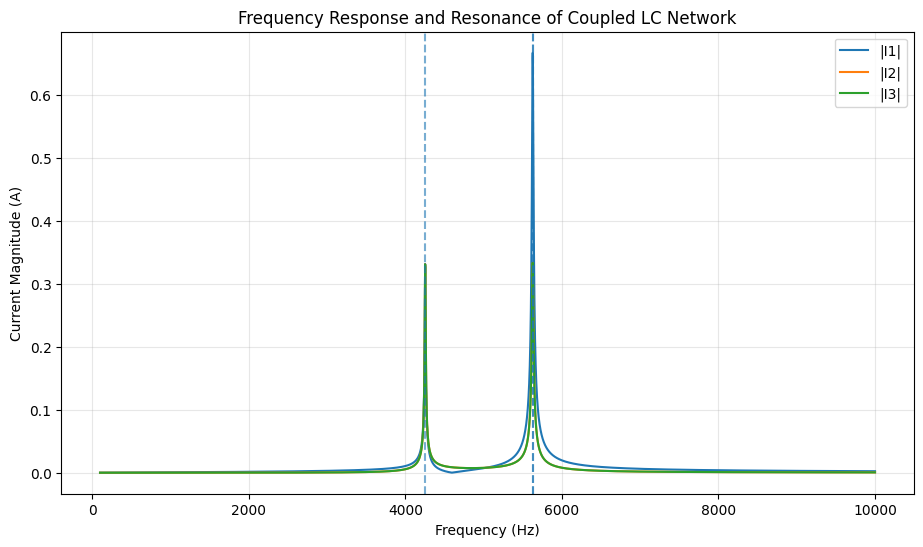

In [ ]:

# ============================================================
# RESONANCE / FREQUENCY RESPONSE PLOT
# ============================================================

plt.figure(figsize=(11, 6))

plt.plot(frequencies, response[0], label="|I1|")
plt.plot(frequencies, response[1], label="|I2|")
plt.plot(frequencies, response[2], label="|I3|")

# Mark theoretical natural frequencies
for f in frequency:
    plt.axvline(
        f,
        linestyle="--",
        alpha=0.6
    )

plt.xlabel("Frequency (Hz)")
plt.ylabel("Current Magnitude (A)")
plt.title("Frequency Response and Resonance of Coupled LC Network")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:

# ============================================================
# FIND APPROXIMATE RESPONSE PEAKS
# ============================================================

total_response = np.linalg.norm(response, axis=0)

# Simple local-maximum detection
peak_indices = []

for i in range(1, len(total_response) - 1):
    if (
        total_response[i] > total_response[i - 1]
        and total_response[i] > total_response[i + 1]
    ):
        peak_indices.append(i)

# Keep the strongest peaks
peak_indices = sorted(
    peak_indices,
    key=lambda i: total_response[i],
    reverse=True
)[:3]

peak_indices = sorted(peak_indices)

print("\nAPPROXIMATE RESONANCE PEAKS")
print("=" * 45)

for i in peak_indices:
    print(
        f"Frequency = {frequencies[i]:.2f} Hz   "
        f"|I| = {total_response[i]:.4f} A"
    )


APPROXIMATE RESONANCE PEAKS
Frequency = 4252.89 Hz   |I| = 0.5730 A
Frequency = 5627.29 Hz   |I| = 0.8161 A


In [ ]:

# ============================================================
# COMPARISON
# ============================================================

print("\n" + "=" * 70)
print("THEORETICAL NATURAL FREQUENCY vs RESPONSE RESONANCE")
print("=" * 70)

print(
    f"{'Mode':<10}"
    f"{'Natural Frequency (Hz)':<25}"
    f"{'Nearest Response (Hz)':<25}"
)

print("-" * 70)

for k, f_nat in enumerate(frequency):

    nearest_index = np.argmin(
        np.abs(frequencies - f_nat)
    )

    f_response = frequencies[nearest_index]

    print(
        f"{k+1:<10}"
        f"{f_nat:<25.4f}"
        f"{f_response:<25.4f}"
    )

print("=" * 70)


THEORETICAL NATURAL FREQUENCY vs RESPONSE RESONANCE
Mode      Natural Frequency (Hz)   Nearest Response (Hz)    
----------------------------------------------------------------------
1         4253.5948                4252.8906                
2         5626.9770                5627.2855                
3         5626.9770                5627.2855                


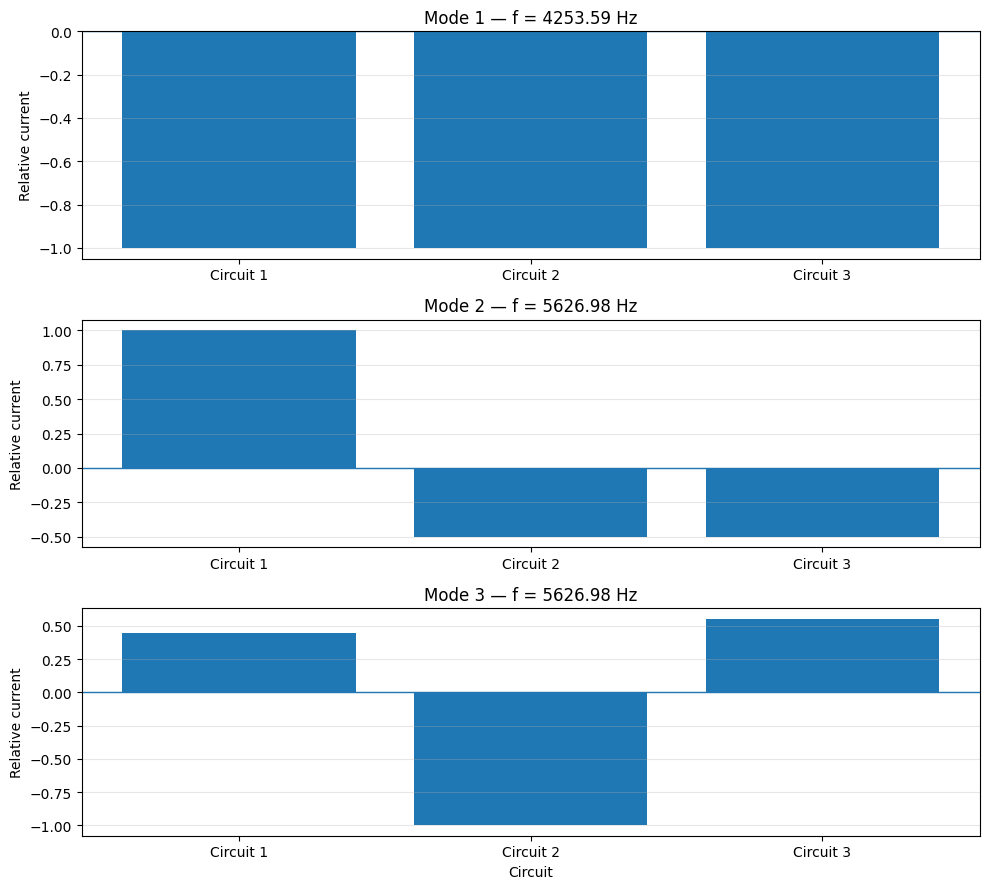

In [ ]:

# ============================================================
# MODE SHAPES
# ============================================================

fig, axes = plt.subplots(3, 1, figsize=(10, 9))

for k in range(3):

    axes[k].bar(
        ["Circuit 1", "Circuit 2", "Circuit 3"],
        eigenvectors[:, k]
    )

    axes[k].axhline(0, linewidth=1)

    axes[k].set_ylabel("Relative current")
    axes[k].set_title(
        f"Mode {k+1} — f = {frequency[k]:.2f} Hz"
    )

    axes[k].grid(axis="y", alpha=0.3)

axes[-1].set_xlabel("Circuit")

plt.tight_layout()
plt.show()

In [ ]:

# ============================================================
# BENCHMARK TEST
# ============================================================

expected = np.array([
    4253.5948,
    5626.9770,
    5626.9770
])

error = np.abs(frequency - expected)

print("BENCHMARK TEST")
print("=" * 50)

for k in range(3):
    print(
        f"Mode {k+1}: "
        f"Calculated = {frequency[k]:.4f} Hz, "
        f"Expected ≈ {expected[k]:.4f} Hz, "
        f"Error = {error[k]:.6f} Hz"
    )

if np.all(error < 0.1):
    print("\n✓ Benchmark test PASSED")
else:
    print("\n✗ Benchmark test needs investigation")

BENCHMARK TEST
Mode 1: Calculated = 4253.5948 Hz, Expected ≈ 4253.5948 Hz, Error = 0.000025 Hz
Mode 2: Calculated = 5626.9770 Hz, Expected ≈ 5626.9770 Hz, Error = 0.000024 Hz
Mode 3: Calculated = 5626.9770 Hz, Expected ≈ 5626.9770 Hz, Error = 0.000024 Hz

✓ Benchmark test PASSED


In [ ]:

# ============================================================
# FINAL SUMMARY
# ============================================================

print("""
===============================================================
                  PROJECT CONCLUSION
===============================================================

1. The coupled LC network was represented using matrices.

2. The circuit equation is:

       L d²i/dt² + C⁻¹ i = 0

3. Assuming a natural-mode solution:

       i(t) = u exp(jωt)

   gives:

       L⁻¹C⁻¹u = ω²u

4. Therefore:

       Eigenvalue = ω²
       Eigenvector = current distribution

5. The eigenvalues give the three natural frequencies.

6. The eigenvectors show how currents i1, i2 and i3
   participate in each natural mode.

7. When the network is driven near a natural frequency,
   resonance occurs and the current response becomes large.

8. A small resistance was used only in the driven-response
   simulation to make the resonance peaks finite and visible.

===============================================================
""")


                  PROJECT CONCLUSION

1. The coupled LC network was represented using matrices.

2. The circuit equation is:

       L d²i/dt² + C⁻¹ i = 0

3. Assuming a natural-mode solution:

       i(t) = u exp(jωt)

   gives:

       L⁻¹C⁻¹u = ω²u

4. Therefore:

       Eigenvalue = ω²
       Eigenvector = current distribution

5. The eigenvalues give the three natural frequencies.

6. The eigenvectors show how currents i1, i2 and i3
   participate in each natural mode.

7. When the network is driven near a natural frequency,
   resonance occurs and the current response becomes large.

8. A small resistance was used only in the driven-response
   simulation to make the resonance peaks finite and visible.




In [ ]:

# ============================================================
# ENERGY DISTRIBUTION OF EACH NATURAL MODE
# ============================================================

# For a natural mode, the eigenvector gives the relative
# current distribution:
#
#       u = [i1, i2, i3]
#
# Since the magnetic energy depends on current, we use:
#
#       E_i ∝ L_i * |i_i|²
#
# This gives the relative magnetic-energy contribution
# of each individual inductor.
#
# IMPORTANT:
# This is a relative visualization of energy participation,
# not the complete coupled-inductor energy calculation.

energy = np.zeros((3, 3))

for mode in range(3):

    # Current distribution of this mode
    current = eigenvectors[:, mode]

    # Relative energy contribution
    energy[:, mode] = (
        np.array([L1, L2, L3]) *
        np.abs(current)**2
    )

    # Convert to percentage

In [ ]:

# ============================================================
# COUPLING COMPARISON
# Compare: Without Coupling vs With Coupling
# ============================================================

def calculate_natural_frequencies(L_values, C_values, M12, M13, M23):
    """
    Calculate natural frequencies of the 3 coupled LC circuits.

    Eigenvalue equation:
        L^-1 C^-1 u = w^2 u

    Eigenvalues = w^2
    """

    L1, L2, L3 = L_values
    C1, C2, C3 = C_values

    # Inductance matrix
    L = np.array([
        [L1,  M12, M13],
        [M12, L2,  M23],
        [M13, M23, L3]
    ], dtype=float)

    # Capacitance matrix
    C = np.diag([C1, C2, C3])

    # C^-1
    C_inv = np.linalg.inv(C)

    # Eigenvalue matrix
    A = np.linalg.solve(L, C_inv)

    # Eigenvalues and eigenvectors
    eigenvalues, eigenvectors = np.linalg.eig(A)

    eigenvalues = np.real(eigenvalues)

    # Natural angular frequencies
    omega = np.sqrt(eigenvalues)

    # Hz
    frequency = omega / (2 * np.pi)

    # Sort
    frequency = np.sort(frequency)

    return frequency


# ------------------------------------------------------------
# Circuit parameters
# ------------------------------------------------------------

L_values = [L1, L2, L3]
C_values = [C1, C2, C3]


# ------------------------------------------------------------
# CASE 1: WITHOUT COUPLING
# M12 = M13 = M23 = 0
# ------------------------------------------------------------

frequency_without = calculate_natural_frequencies(
    L_values,
    C_values,
    0,
    0,
    0
)


# ------------------------------------------------------------
# CASE 2: WITH COUPLING
# Use the mutual inductances from our project
# ------------------------------------------------------------

frequency_with = calculate_natural_frequencies(
    L_values,
    C_values,
    M12,
    M13,
    M23
)


print("Coupling comparison calculation completed.")

Coupling comparison calculation completed.
